In [1]:
import numpy as np
import pyshtools as pysh
import boule as bl
import pandas as pd
import xarray as xr
import harmonica as hm
import verde as vd
from pathlib import Path

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

pygmt-session [ERROR]: Cannot find the PSL_UTF-8 encoding
begin [ERROR]: Cannot find the PSL_UTF-8 encoding
d:\conda_envs\planet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path.cwd().parent
data_filename=PROJECT_ROOT/"data/boueguer_frenquency_11km_1deg.csv"
result_filename=PROJECT_ROOT/"data/boueguer_frenquency_11km_withoutmoremare_topo_1deg.csv"
height=11e3

In [3]:
def carplot(da, title="", cbar_label="", cmap="jet", filename=None):
    """
    最简单 PlateCarree 绘图。支持 lon 为 0-360 或 -180-180：
    自动 wrap 到 [-180,180) 并按经度排序，避免 0/360 接缝问题。
    """
    lon = da["lon"].values.astype(float)
    lat = da["lat"].values.astype(float)
    data = da.values

    # wrap 0..360 -> [-180, 180)
    if np.nanmax(lon) > 180:
        lon_wrapped = ((lon + 180) % 360) - 180
        idx = np.argsort(lon_wrapped)
        lon_plot = lon_wrapped[idx]
        data_plot = data[:, idx]
    else:
        lon_plot = lon
        data_plot = data

    fig = plt.figure(figsize=(10, 4.8), dpi=150)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    mesh = ax.pcolormesh(
        lon_plot, lat, data_plot,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap
    )

    ax.set_title(title)
    cbar = plt.colorbar(mesh, ax=ax, shrink=0.85, pad=0.03)
    if cbar_label:
        cbar.set_label(cbar_label)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches="tight")
    plt.show()
    return fig, ax
'''
basins = [
    ("Imbrium",     36.8,  -15.6, 650),   # ~1300 km 直径
    ("Serenitatis", 28.0,   17.5, 460),   # ~920 km
    ("Crisium",     17.0,   59.0, 530),   # ~1060 km
    ("Smythii",     -1.3,   87.5, 370),   # ~740 km
    ("Nectaris",   -15.2,   34.6, 430),   # ~860 km
    ("Humorum",    -24.4,  -38.6, 425),   # ~850 km
    ("Orientale",  -19.4,  -92.8, 465),   # ~930 km
    ("Grimaldi",    -5.5,  -68.3, 200),   # ~400 km
]
'''
basins = [
    ("Grimaldi", -5.0, -68.0, 215),
    ("Serenitatis", 27.0, 19.0, 370),
    ("Humorum", -24.0, -39.5, 410),
    ("Smythii", -2.0, 87.0, 420),
    ("Nectaris", -16.0, 34.0, 430),
    ("Orientale", -20.0, -95.0, 465),
    ("Crisium", 17.5, 58.5, 530),
    ("Imbrium", 33.0, -18.0, 580),
]


def carplot_basins(da, basins, save_path=None, title="",
                   cbar_label="Bouguer gravity anomaly (mGal)", cmap="jet"):
    lon = da["lon"].values.astype(float)
    lat = da["lat"].values.astype(float)
    data = da.values

    # wrap 到 [-180,180)
    if np.nanmax(lon) > 180:
        lon_wrapped = ((lon + 180) % 360) - 180
        idx = np.argsort(lon_wrapped)
        lon_plot = lon_wrapped[idx]
        data_plot = data[:, idx]
    else:
        lon_plot = lon
        data_plot = data

    fig = plt.figure(figsize=(10, 4.8), dpi=150)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    mesh = ax.pcolormesh(
        lon_plot, lat, data_plot,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap
    )

    # colorbar
    cbar = plt.colorbar(mesh, ax=ax, shrink=0.85, pad=0.03)
    if cbar_label:
        cbar.set_label(cbar_label)

    # 盆地圈：km -> 度（沿大圆的角半径）
    R_moon_km = bl.Moon2015.mean_radius * 1e-3  # km
    for name, lat_c, lon_c, radius_km in basins:
        ang_rad = radius_km / R_moon_km           # radians
        ang_deg = np.rad2deg(ang_rad)             # degrees（角半径）

        circ = mpatches.Circle(
            (lon_c, lat_c),
            radius=ang_deg,
            transform=ccrs.PlateCarree(),
            fill=False,
            linewidth=1.0,
            edgecolor="black",
            zorder=5,
        )
        ax.add_patch(circ)

        ax.text(
            lon_c, lat_c, name,
            transform=ccrs.PlateCarree(),
            ha="center", va="center",
            fontsize=8, fontweight="bold",
            color="black",
            zorder=6
        )

    if title:
        ax.set_title(title)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"图已保存至: {save_path}")
    plt.show()
    return fig, ax

In [4]:
# 读取数据
df = pd.read_csv(data_filename)
# df = pd.read_csv(r'data\moon_1deg_data.csv')

lon_raw = np.sort(df['lon'].unique())
lat_raw = np.sort(df['lat'].unique())

lon_raw = lon_raw - 180

grav_values = df.pivot(index='lat', columns='lon', values='deltaN').loc[lat_raw, df['lon'].unique()].values
topo_values = df.pivot(index='lat', columns='lon', values='topo').loc[lat_raw, df['lon'].unique()].values

nlon = grav_values.shape[1]
half = nlon // 2
grav_swapped = np.hstack([
    grav_values[:, half:],
    grav_values[:, :half]
])

lon_grid, lat_grid = np.meshgrid(lon_raw, lat_raw)

grav_da = xr.DataArray(
    grav_swapped,
    dims=("lat", "lon"),
    coords={
        "lat": lat_raw,
        "lon": lon_raw
    },
    name="bouguer_anomaly",
    attrs={"units": "mGal", "long_name": "Bouguer gravity anomaly"}
)

topo_da = xr.DataArray(
    topo_values,
    dims=("lat", "lon"),
    coords={
        "lat": lat_raw,
        "lon": lon_raw
    },
    name="topography",
    attrs={"units": "m", "long_name": "Topography height"}
)

ds = xr.Dataset(
    {
        "bouguer_anomaly": grav_da,
        "topography": topo_da
    }
)

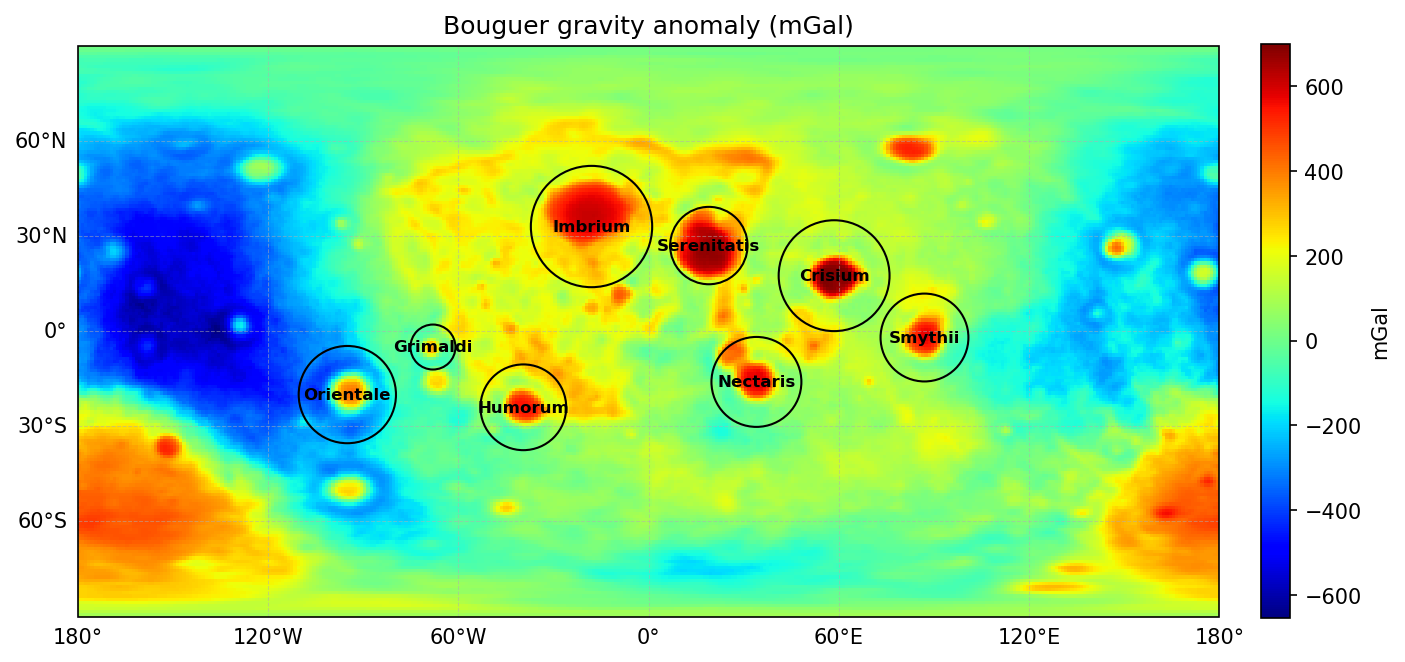

(<Figure size 1500x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Bouguer gravity anomaly (mGal)'}>)

In [5]:
carplot_basins(
    grav_da,
    basins=basins,
    title="Bouguer gravity anomaly (mGal)",
    cbar_label="mGal"
)

月海深度 $\log_{10}(d)=0.41\times [\log_{10}(D)]^{0.57}$

In [6]:
import math

def calculate_depth(D):
    log_D = math.log10(D)
    exponent_part = log_D ** 0.57  # 先算 (log10(D))^0.57
    log_d = 0.41 * exponent_part   # 再乘以 0.41
    d = 10 ** log_d
    return d

basins_with_depth = []

for name, lat, lon, radius_km in basins:
    diameter_km = 2 * radius_km
    depth_km = calculate_depth(diameter_km)
    basins_with_depth.append((name, lat, lon, radius_km, diameter_km, depth_km))
    
    print(f"{name:12s}: D = {diameter_km:5.0f} km,  估算深度 d = {depth_km:.1f} km")

Grimaldi    : D =   430 km,  估算深度 d = 5.2 km
Serenitatis : D =   740 km,  估算深度 d = 5.6 km
Humorum     : D =   820 km,  估算深度 d = 5.7 km
Smythii     : D =   840 km,  估算深度 d = 5.7 km
Nectaris    : D =   860 km,  估算深度 d = 5.7 km
Orientale   : D =   930 km,  估算深度 d = 5.8 km
Crisium     : D =  1060 km,  估算深度 d = 5.9 km
Imbrium     : D =  1160 km,  估算深度 d = 6.0 km


月海建模

In [7]:
def calculate_depth(D):
    """根据你提供的经验公式计算盆地最大深度 (km)"""
    log_D = math.log10(D)
    exponent_part = log_D ** 0.57
    log_d = 0.41 * exponent_part
    d = 10 ** log_d
    return d

basin_list = []
for name, lat_c, lon_c, radius_km in basins:
    diameter_km = 2 * radius_km
    depth_max = calculate_depth(diameter_km)
    basin_list.append((name, lat_c, lon_c, radius_km, depth_max))
    print(f"{name:12s}: 直径 {diameter_km:5.0f} km → 估算最大深度 {depth_max:.1f} km")
    
region=(0, 359.99999, -90, 90)
grid_longitude, grid_latitude = vd.grid_coordinates(region=region, shape=(181,361))
lon_o=np.sort(np.unique(grid_longitude))
lat_o=np.sort(np.unique(grid_latitude))
lon = 0.5 * (lon_o[:-1] + lon_o[1:])
lat = 0.5 * (lat_o[:-1] + lat_o[1:])
lon-=180
Lon, Lat = np.meshgrid(lon, lat)

Lon_rad = np.deg2rad(Lon)
Lat_rad = np.deg2rad(Lat)

Grimaldi    : 直径   430 km → 估算最大深度 5.2 km
Serenitatis : 直径   740 km → 估算最大深度 5.6 km
Humorum     : 直径   820 km → 估算最大深度 5.7 km
Smythii     : 直径   840 km → 估算最大深度 5.7 km
Nectaris    : 直径   860 km → 估算最大深度 5.7 km
Orientale   : 直径   930 km → 估算最大深度 5.8 km
Crisium     : 直径  1060 km → 估算最大深度 5.9 km
Imbrium     : 直径  1160 km → 估算最大深度 6.0 km


In [8]:
basin_depth = np.zeros_like(Lon, dtype=float)

R_moon = bl.Moon2015.mean_radius * 1e-3  # km

# 角度统一转弧度
Lat_rad = np.deg2rad(Lat)
Lon_rad = np.deg2rad(Lon)

for basin in basin_list:
    name, lat_c, lon_c, radius_km, depth_max = basin

    lat_c_rad = np.deg2rad(lat_c)
    lon_c_rad = np.deg2rad(lon_c)

    delta_lat = Lat_rad - lat_c_rad

    delta_lon = (Lon_rad - lon_c_rad + np.pi) % (2 * np.pi) - np.pi

    # Haversine
    a = (
        np.sin(delta_lat / 2.0) ** 2
        + np.cos(Lat_rad) * np.cos(lat_c_rad) * np.sin(delta_lon / 2.0) ** 2
    )

    # 数值安全
    a = np.clip(a, 0.0, 1.0)

    delta_sigma = 2.0 * np.atan2(np.sqrt(a), np.sqrt(1.0 - a))
    d = R_moon * delta_sigma  # km

    mask = d <= radius_km

    # 盆地局部抛物面深度（边界处为 0，中心为 -depth_max）
    depth_local = np.zeros_like(Lon, dtype=float)
    depth_local[mask] = -depth_max * (1.0 - (d[mask] / radius_km) ** 2)
    
    basin_depth[mask] = np.minimum(basin_depth[mask], depth_local[mask])

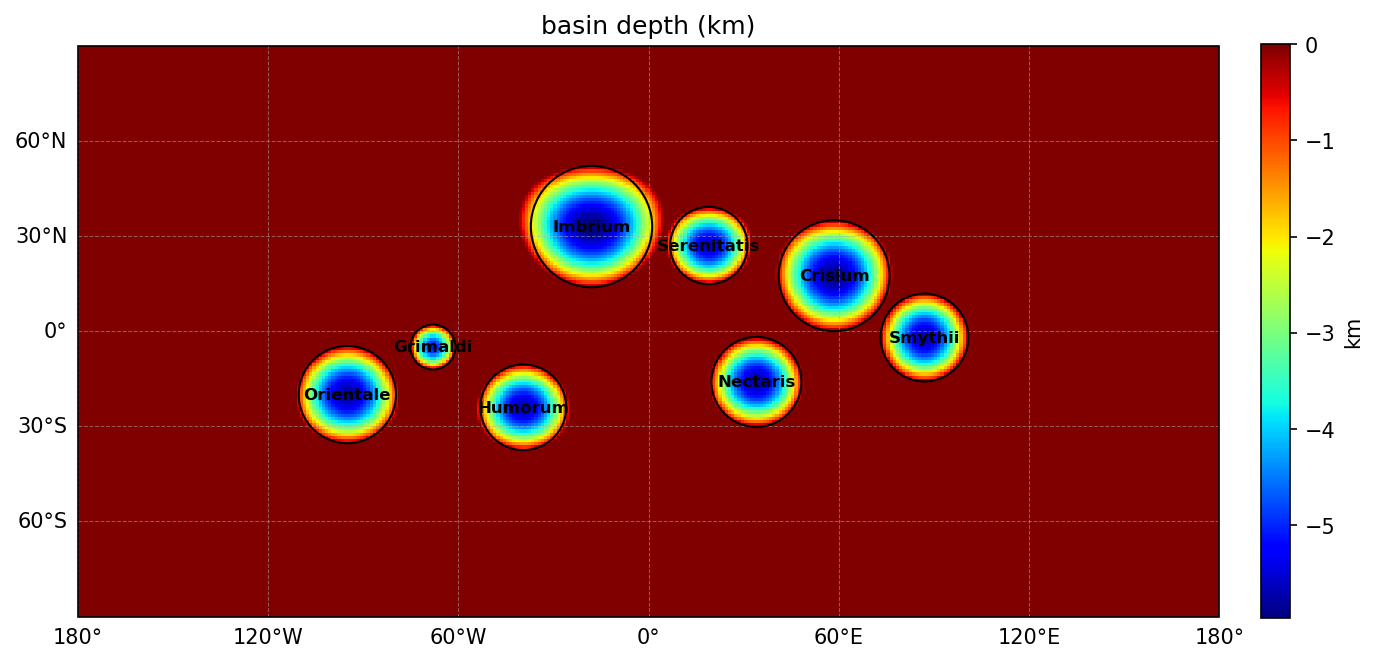

(<Figure size 1500x720 with 2 Axes>,
 <GeoAxes: title={'center': 'basin depth (km)'}>)

In [ ]:
depth_da = xr.DataArray(
    basin_depth,
    dims=("lat", "lon"),
    coords={
        "lat": lat,
        "lon": lon,
    },
    name="basin_depth"
)
carplot_basins(
    depth_da,
    basins=basins,
    title="盆地深度 (km)",
    cbar_label="km"
)

In [10]:
surface=bl.Moon2015.mean_radius+topo_values+basin_depth*1e3
reference=bl.Moon2015.mean_radius+topo_values
density_array=(3159-2794)*np.ones_like(depth_da.data)

In [11]:
mare_layer=hm.tesseroid_layer((lon,lat),surface=surface,reference=reference,properties={"density":density_array})
coordinates=(Lon,Lat,reference+height)
topo_g=mare_layer.tesseroid_layer.gravity(coordinates, field="g_z",progressbar=False)

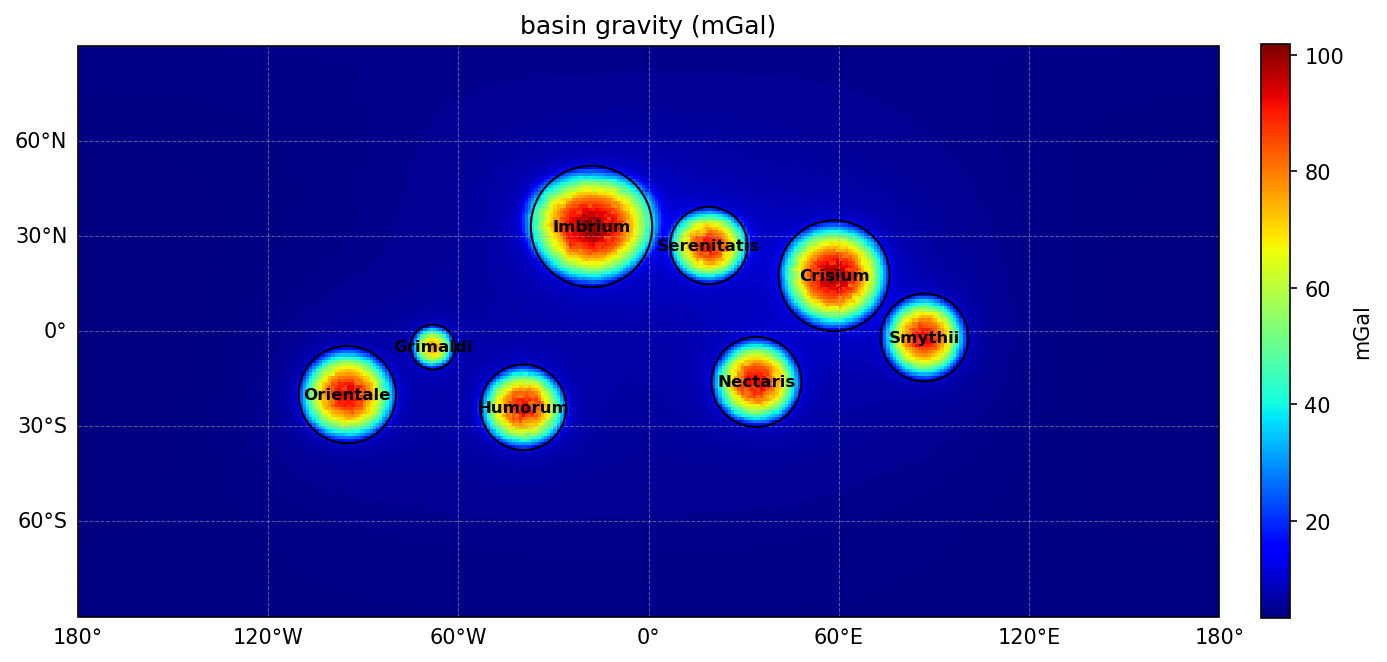

(<Figure size 1500x720 with 2 Axes>,
 <GeoAxes: title={'center': 'basin gravity (mGal)'}>)

In [12]:
depth_da = xr.DataArray(
    topo_g,
    dims=("lat", "lon"),
    coords={
        "lat": lat,
        "lon": lon,
    },
    name="basin_depth"
)
depth_da=depth_da.interp_like(grav_da,kwargs={"fill_value": "extrapolate"})
carplot_basins(
    depth_da,
    basins=basins,
    title="basin gravity (mGal)",
    cbar_label="mGal"
)

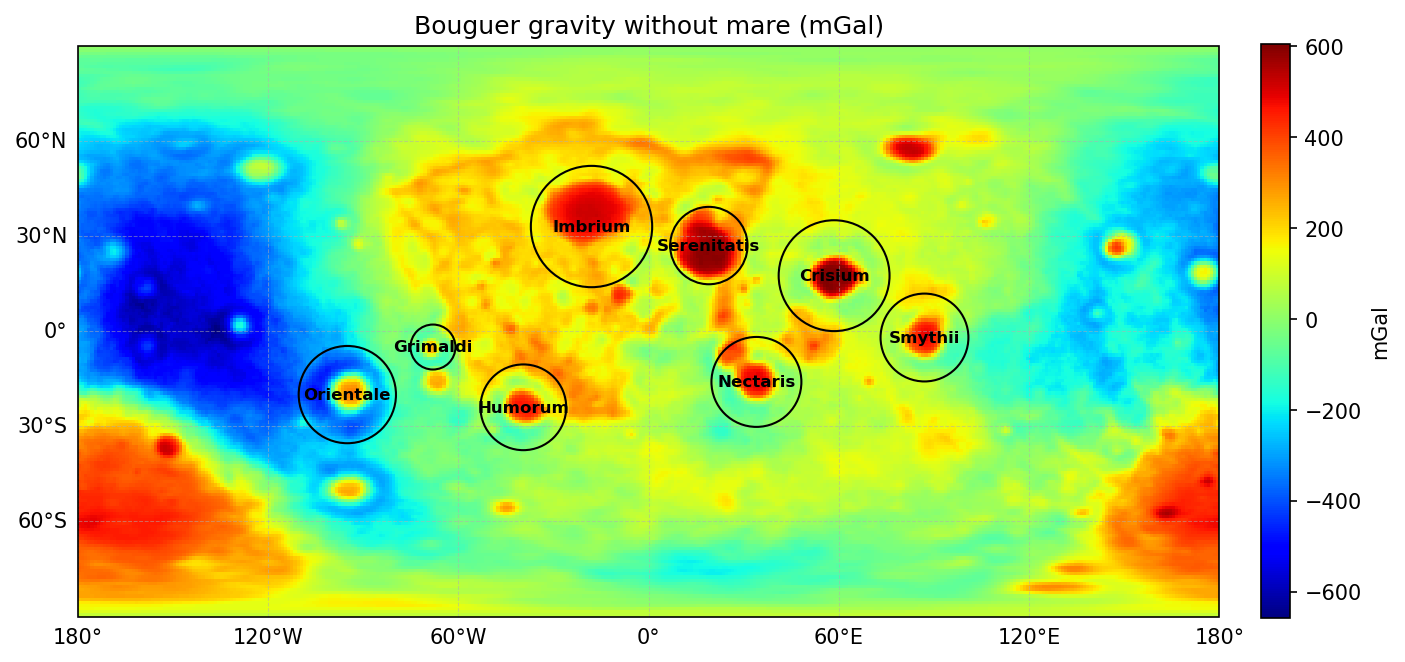

(<Figure size 1500x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Bouguer gravity without mare (mGal)'}>)

In [13]:
grav_da.data-=depth_da.data
carplot_basins(
    grav_da,
    basins=basins,
    title="Bouguer gravity without mare (mGal)",
    cbar_label="mGal"
)

In [14]:
depth_da

<xarray.DataArray 'basin_depth' (lat: 180, lon: 360)> Size: 518kB
array([[4.02120163, 4.02121624, 4.02123327, ..., 4.0211713 , 4.02117927,
        4.02118934],
       [4.00350712, 4.0034846 , 4.00348401, ..., 4.00367087, 4.0036048 ,
        4.00354855],
       [3.98826173, 3.988484  , 3.98870959, ..., 3.98772455, 3.98787419,
        3.9880552 ],
       ...,
       [4.41824235, 4.41803529, 4.41785084, ..., 4.41898393, 4.41871712,
        4.41846997],
       [4.45406175, 4.45395393, 4.45386192, ..., 4.45448102, 4.45432512,
        4.45418544],
       [4.49088297, 4.49084774, 4.49081822, ..., 4.49102282, 4.49097052,
        4.4909239 ]], shape=(180, 360))
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5

In [15]:
df=(
    grav_da
    .stack(points=('lat','lon'))
    .reset_index('points')
    .to_dataframe(name='deltaN')
    .reset_index(drop=True)
)
topo_da.data=topo_da.data-bl.Moon2015.mean_radius
topo_da=topo_da.interp_like(grav_da)
df_topo=(
    topo_da
    .stack(points=('lat','lon'))
    .reset_index('points')
    .to_dataframe(name='topo')
    .reset_index(drop=True)
)
df=df.merge(df_topo,on=['lon', 'lat'],how='left')
df


,lat,lon,deltaN,topo
0,-89.5,-179.50000,84.763629,-1.737737e+06
1,-89.5,-178.50000,84.753730,-1.737711e+06
2,-89.5,-177.50000,84.742168,-1.737685e+06
3,-89.5,-176.50000,84.729010,-1.737658e+06
4,-89.5,-175.50000,84.714328,-1.737631e+06
...,...,...,...,...
64795,89.5,175.49999,-1.227144,-1.737926e+06
64796,89.5,176.49999,-1.265256,-1.737944e+06
64797,89.5,177.49999,-1.303594,-1.737961e+06
64798,89.5,178.49999,-1.342261,-1.737978e+06


In [16]:
df.to_csv(
    result_filename,
    index=False,        # 不输出行号
    float_format='%.6f' # 控制浮点精度，重力数据一般够用
)